In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import joblib

In [3]:
data = {
    "query": [
        # WEATHER FORECAST
        "Will it rain tomorrow?",
        "Will it rain tomorrow in Vijayawada?",
        "What will the weather be tomorrow?",
        "Give me tomorrow's weather forecast",
        "Is rain expected tomorrow evening?",
        "Will it be sunny tomorrow?",
        "What is the forecast for next week?",
        "Will there be heavy rain tonight?",
        "Tell me the weather forecast",
        "What weather can I expect tomorrow?",
        # CURRENT WEATHER
        "What is the weather now?",
        "What is the current temperature?",
        "Is it raining right now?",
        "Tell me the weather currently",
        "How hot is it now?",
        "What is the temperature in Chennai right now?",
        "Is it windy outside now?",
        "What is the current weather in Vijayawada?",
        "How is the weather today?",
        "What is happening with the weather now?",
        # TRAVEL WEATHER
        "Should I travel tomorrow?",
        "Is it safe to travel tonight?",
        "Can I drive to Chennai tomorrow?",
        "Will the weather affect my journey?",
        "Should I take my trip this evening?",
        "Is it safe to drive in this rain?",
        "Will my flight be affected by weather?",
        "Should I travel during the storm?",
        "Can I go outside tonight?",
        "Will rain affect my travel?",
        # WEATHER WARNING
        "Is there any weather warning?",
        "Is there a rain alert?",
        "Do we have a cyclone warning?",
        "Is there any dangerous weather alert?",
        "Tell me about weather warnings",
        "Is there a red alert?",
        "Has any official warning been issued?",
        "Are there storm warnings?",
        "Is there a heavy rain warning?",
        "Are there any alerts for my area?",
        # AGRICULTURE
        "My paddy crop needs advice",
        "Should I irrigate my crops?",
        "Will rain affect my paddy?",
        "What should farmers do before heavy rain?",
        "Give me weather advice for farming",
        "Should I harvest my crop tomorrow?",
        "Will heavy rain damage my crops?",
        "I need agricultural weather advice",
        "What should I do with my farm today?",
        "Is this weather good for agriculture?",
        # WEATHER RISK
        "Is there a flood risk?",
        "How dangerous is the weather?",
        "What is the weather risk today?",
        "Is there any risk from heavy rain?",
        "Could flooding happen?",
        "Is it dangerous to go outside?",
        "What is my weather risk?",
        "How severe is the storm?",
        "Is the rainfall situation dangerous?",
        "Should I be worried about the weather?",
    ],
    "intent": (
        ["weather_forecast"] * 10
        + ["current_weather"] * 10
        + ["travel_weather"] * 10
        + ["weather_warning"] * 10
        + ["agriculture_advisory"] * 10
        + ["weather_risk"] * 10
    ),
}

df = pd.DataFrame(data)
df.head()

,query,intent
0,Will it rain tomorrow?,weather_forecast
1,Will it rain tomorrow in Vijayawada?,weather_forecast
2,What will the weather be tomorrow?,weather_forecast
3,Give me tomorrow's weather forecast,weather_forecast
4,Is rain expected tomorrow evening?,weather_forecast


In [4]:
print("Dataset shape:", df.shape)

print("\nIntent distribution:")
print(df["intent"].value_counts())

Dataset shape: (60, 2)

Intent distribution:
intent
weather_forecast        10
current_weather         10
travel_weather          10
weather_warning         10
agriculture_advisory    10
weather_risk            10
Name: count, dtype: int64


In [5]:
X = df["query"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 45
Testing examples: 15


In [6]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [7]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8

Classification Report:

                      precision    recall  f1-score   support

agriculture_advisory       0.50      1.00      0.67         2
     current_weather       1.00      1.00      1.00         2
      travel_weather       1.00      0.67      0.80         3
    weather_forecast       0.75      1.00      0.86         3
        weather_risk       1.00      0.67      0.80         3
     weather_warning       1.00      0.50      0.67         2

            accuracy                           0.80        15
           macro avg       0.88      0.81      0.80        15
        weighted avg       0.88      0.80      0.80        15



In [9]:
test_queries = [
    "Will it rain in Vijayawada tomorrow?",
    "What is the temperature right now?",
    "Should I travel tonight?",
    "Is there a cyclone alert?",
    "What should I do with my paddy crop?",
    "Is there a flood danger?"
]

for query in test_queries:

    prediction = model.predict([query])[0]

    probabilities = model.predict_proba([query])[0]

    confidence = probabilities.max()

    print("Query:", query)
    print("Intent:", prediction)
    print("Confidence:", round(confidence, 3))
    print("-" * 50)

Query: Will it rain in Vijayawada tomorrow?
Intent: weather_forecast
Confidence: 0.343
--------------------------------------------------
Query: What is the temperature right now?
Intent: current_weather
Confidence: 0.381
--------------------------------------------------
Query: Should I travel tonight?
Intent: travel_weather
Confidence: 0.313
--------------------------------------------------
Query: Is there a cyclone alert?
Intent: weather_warning
Confidence: 0.385
--------------------------------------------------
Query: What should I do with my paddy crop?
Intent: agriculture_advisory
Confidence: 0.355
--------------------------------------------------
Query: Is there a flood danger?
Intent: agriculture_advisory
Confidence: 0.189
--------------------------------------------------


In [10]:
results = pd.DataFrame({
    "query": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

incorrect = results[
    results["actual"] != results["predicted"]
]

incorrect

,query,actual,predicted
0,Should I take my trip this evening?,travel_weather,weather_forecast
10,Could flooding happen?,weather_risk,agriculture_advisory
11,Are there any alerts for my area?,weather_warning,agriculture_advisory


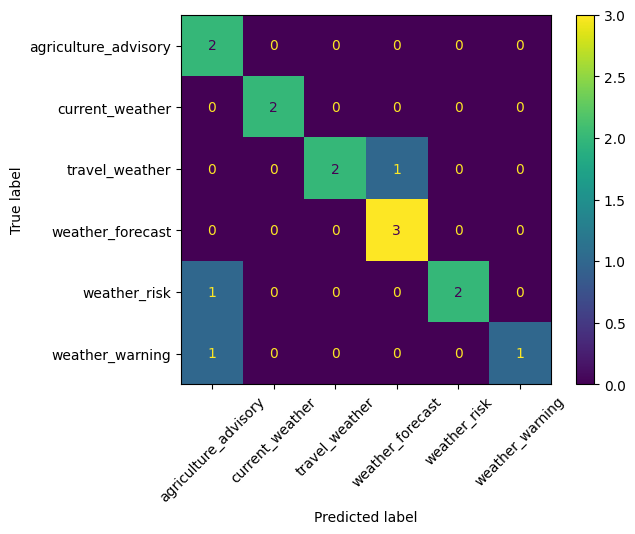

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

display.plot(
    xticks_rotation=45
)

In [12]:
additional_data = {
    "query": [

        # TRAVEL WEATHER
        "Should I take my trip this evening?",
        "Can I travel this evening?",
        "Is my journey safe today?",
        "Will bad weather affect my trip?",
        "Should I leave for my journey now?",
        "Can weather delay my journey?",
        "Is it safe to go on a road trip?",
        "Will rain make my trip difficult?",
        "Should I postpone my journey because of weather?",
        "Is the weather suitable for travelling?",

        # WEATHER RISK
        "Could flooding happen?",
        "Is flooding possible?",
        "Is there a danger of flood?",
        "Could heavy rain cause flooding?",
        "Is my area at risk of flooding?",
        "Will the river overflow?",
        "Is there any danger from the storm?",
        "Could severe weather affect my area?",
        "Is the situation becoming dangerous?",
        "Is there a serious weather threat?",

        # WEATHER WARNING
        "Are there any alerts for my area?",
        "Has a weather alert been issued?",
        "Do I have any alerts nearby?",
        "Are there official warnings today?",
        "Is my district under an alert?",
        "Has the government issued a weather warning?",
        "Is there an emergency weather alert?",
        "Are any official alerts active?",
        "What alerts are active in my location?",
        "Has an alert been issued for heavy rain?"
    ],

    "intent": (

        ["travel_weather"] * 10 +

        ["weather_risk"] * 10 +

        ["weather_warning"] * 10
    )
}

additional_df = pd.DataFrame(additional_data)

df = pd.concat(
    [df, additional_df],
    ignore_index=True
)

print("New dataset size:", df.shape)

print("\nNew intent distribution:")
print(df["intent"].value_counts())

New dataset size: (90, 2)

New intent distribution:
intent
weather_warning         20
travel_weather          20
weather_risk            20
weather_forecast        10
current_weather         10
agriculture_advisory    10
Name: count, dtype: int64


In [13]:
X = df["query"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 67
Testing examples: 23


In [14]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

print("Model created successfully")

Model created successfully


In [15]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.782608695652174

Classification Report:

                      precision    recall  f1-score   support

agriculture_advisory       1.00      0.33      0.50         3
     current_weather       0.33      1.00      0.50         2
      travel_weather       1.00      0.60      0.75         5
    weather_forecast       0.67      0.67      0.67         3
        weather_risk       1.00      1.00      1.00         5
     weather_warning       1.00      1.00      1.00         5

            accuracy                           0.78        23
           macro avg       0.83      0.77      0.74        23
        weighted avg       0.90      0.78      0.79        23



In [17]:
results = pd.DataFrame({
    "query": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

incorrect = results[
    results["actual"] != results["predicted"]
]

incorrect

,query,actual,predicted
3,I need agricultural weather advice,agriculture_advisory,current_weather
9,Should I travel tomorrow?,travel_weather,weather_forecast
17,Can I go outside tonight?,travel_weather,current_weather
18,Tell me the weather forecast,weather_forecast,current_weather
20,Give me weather advice for farming,agriculture_advisory,current_weather


In [18]:
additional_data_2 = {
    "query": [

        # CURRENT WEATHER
        "What is the temperature now?",
        "How is the weather right now?",
        "Is it raining at the moment?",
        "What are the conditions outside now?",
        "Tell me the current temperature",
        "Is it hot right now?",
        "How much rain is falling now?",
        "What is the weather like at this moment?",
        "Is it cloudy now?",
        "What is happening with the weather currently?",

        # AGRICULTURE ADVISORY
        "What should I do with my crops today?",
        "Should I irrigate my field today?",
        "Will tomorrow's rain affect my crops?",
        "What weather advice do you have for farmers?",
        "Should I harvest before the rain?",
        "Will strong winds damage my farm?",
        "What should I do with my paddy field?",
        "Is this weather suitable for planting?",
        "How should farmers prepare for heavy rainfall?",
        "What farming action should I take because of the weather?",

        # WEATHER FORECAST
        "What will the weather be like later today?",
        "What weather is expected this evening?",
        "Will it rain later?",
        "Give me the forecast for tonight",
        "What is expected tomorrow morning?",
        "How will the weather change tomorrow?",
        "What will the temperature be tomorrow?",
        "Is heavy rain expected later today?",
        "Tell me the weather prediction for tomorrow",
        "What conditions are expected in the coming days?"
    ],

    "intent": (

        ["current_weather"] * 10 +
        ["agriculture_advisory"] * 10 +
        ["weather_forecast"] * 10
    )
}

additional_df_2 = pd.DataFrame(additional_data_2)

df = pd.concat(
    [df, additional_df_2],
    ignore_index=True
)

print("Dataset shape:", df.shape)
print("\nIntent distribution:")
print(df["intent"].value_counts())

Dataset shape: (120, 2)

Intent distribution:
intent
weather_forecast        20
current_weather         20
travel_weather          20
weather_warning         20
agriculture_advisory    20
weather_risk            20
Name: count, dtype: int64


In [19]:
X = df["query"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [20]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            stop_words="english",
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [21]:
y_pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.6
                      precision    recall  f1-score   support

agriculture_advisory       0.57      0.80      0.67         5
     current_weather       0.50      0.40      0.44         5
      travel_weather       1.00      0.40      0.57         5
    weather_forecast       0.44      0.80      0.57         5
        weather_risk       0.50      0.40      0.44         5
     weather_warning       1.00      0.80      0.89         5

            accuracy                           0.60        30
           macro avg       0.67      0.60      0.60        30
        weighted avg       0.67      0.60      0.60        30



In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted"
)

print("Cross-validation scores:")
print(scores)

print("\nMean F1 score:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validation scores:
[0.71111111 0.88311688 0.71071429 0.71626984 0.87830688]

Mean F1 score: 0.7799037999037999
Standard deviation: 0.08234683962616936


In [23]:
import joblib

joblib.dump(model, "weathergpt_intent_model_v1.pkl")

print("Model saved successfully!")

Model saved successfully!


In [24]:
import os

print(os.listdir())

['__notebook__.ipynb', 'weathergpt_intent_model_v1.pkl']


In [25]:
model.fit(X, y)

joblib.dump(
    model,
    "weathergpt_intent_model_v1.pkl"
)

print("Final model trained on complete dataset and saved!")

Final model trained on complete dataset and saved!


In [26]:
loaded_model = joblib.load(
    "weathergpt_intent_model_v1.pkl"
)

test_queries = [
    "Is it raining now?",
    "Will it rain tomorrow?",
    "Are there any weather alerts?",
    "Should I travel tonight?",
    "Will heavy rain damage my crops?",
    "Could flooding happen?"
]

predictions = loaded_model.predict(test_queries)

for query, prediction in zip(
    test_queries,
    predictions
):
    print(f"Query: {query}")
    print(f"Intent: {prediction}")
    print("-" * 40)

Query: Is it raining now?
Intent: current_weather
----------------------------------------
Query: Will it rain tomorrow?
Intent: weather_forecast
----------------------------------------
Query: Are there any weather alerts?
Intent: weather_warning
----------------------------------------
Query: Should I travel tonight?
Intent: travel_weather
----------------------------------------
Query: Will heavy rain damage my crops?
Intent: agriculture_advisory
----------------------------------------
Query: Could flooding happen?
Intent: weather_risk
----------------------------------------
